# Library Imports and Utilities

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

# Loading the Dataset

The Bank Account Fraud (BAF) dataset is a synthetic yet realistic tabular dataset introduced at NeurIPS 2022 for evaluating machine learning methods in fraud detection scenarios . It was generated by applying state-of-the-art tabular data generation techniques (CTGAN) to an anonymized, real-world bank account opening fraud detection dataset.
We used the Bank Account Fraud (BAF) dataset, which contains 1 000 000 instances with a 1.1% anomaly rate. It comprises 18 numerical and 11 categorical features. The 'month' feature was removed prior to experimentation. The data were used after preprocessing (missing values, duplicates, and constant features were removed). F1 and Recall scores were obtained with a threshold of 0.5. We used 9 066 instances for finetuning, of which 100 were anomalies, and the same number (9 066 instances, 100 anomalies) for testing.

In [ ]:
from sklearn.datasets import fetch_openml
df_raw = fetch_openml(data_id=46644, as_frame=True)
print(f"Size: {df_raw.data.shape}")

Size: (1000000, 31)


# Preprocessing

In [ ]:
df_raw.data.head()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0.9,0.356764,27,44,30,0.009697,18.851662,AA,1091,10735.013597,...,1,200.0,0,INTERNET,3.698583,windows,0,1,0,0
1,0.6,0.045919,20,0,20,0.029158,-0.977631,AB,2320,10849.761786,...,0,200.0,0,INTERNET,9.321533,other,1,1,0,0
2,0.1,0.343584,-1,117,70,0.000449,-0.875978,AC,944,7375.881534,...,0,200.0,0,INTERNET,1.410795,windows,0,2,0,0
3,0.5,0.121816,-1,56,20,0.008242,11.078060,AA,2495,12643.154044,...,0,200.0,0,INTERNET,8.095574,other,1,1,0,0
4,0.1,0.103161,-1,21,60,0.043340,22.547734,AA,1728,15990.611954,...,1,200.0,0,INTERNET,22.010295,windows,0,1,0,0


In [ ]:
X = preprocess_dataset(df_raw.data.drop(columns=['month']))
y = df_raw.target.astype(int).loc[X.index].squeeze()
y = replace_target(y)

Constant features were removed: ['device_fraud_count']
Size after preprocessing: (1000000, 29)


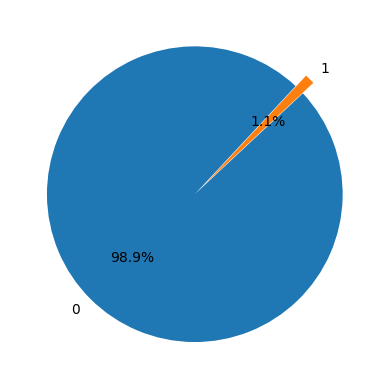

In [ ]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [ ]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 988970
Класс 1 : 11030


In [ ]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Name', 'Values', 'Count of values', 'Type']).sort_values(by=['Count of values', 'Name'])
unique_counts

,Name,Values,Count of values,Type
16,email_is_free,"[1, 0]",2,int64
23,foreign_request,"[0, 1]",2,int64
21,has_other_cards,"[1, 0]",2,int64
27,keep_alive_session,"[0, 1]",2,int64
18,phone_home_valid,"[1, 0]",2,int64
19,phone_mobile_valid,"[1, 0]",2,int64
24,source,"[INTERNET, TELEAPP]",2,object
28,device_distinct_emails_8w,"[1, 2, 0, -1]",4,int64
26,device_os,"[windows, other, linux, macintosh, x11]",5,object
7,payment_type,"[AA, AB, AC, AD, AE]",5,object


In [ ]:
cat_cols = [
    'payment_type',
    'employment_status',
    'housing_status',
    'source',
    'device_os',
    'email_is_free',
    'phone_home_valid',
    'phone_mobile_valid',
    'has_other_cards',
    'foreign_request',
    'keep_alive_session'
]
num_cols = [col for col in X.columns if col not in cat_cols]